# 1,65 MJ/kg en una pirimidona: cinco veces más densidad que el azobenceno

**1,65 megajoules por kilogramo.** Cinco veces más densidad energética que el cis-azobenceno, el material que llevaba 40 años siendo el estándar de los sistemas que guardan luz solar como calor recargable. Una gota de ácido, y el "resorte molecular" se libera: 106 mg de polvo hierven 1 mL de agua.

> **Paper:** Nguyen et al., *Science* (23 abril 2026) — [DOI: 10.1126/science.aec6413](https://doi.org/10.1126/science.aec6413)
>
> [![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-27-pirimidona-dewar-energia-solar/notebook.ipynb)
>
> **Video relacionado:** Pendiente

## El contexto

Los sistemas **MOST** (*Molecular Solar Thermal*) intentan resolver un problema viejo: guardar energía solar en una molécula que, cuando le toca, libera calor a demanda. Hasta ahora el referente era el cis-azobenceno — densidades modestas (~0,3 MJ/kg) y un problema sin resolver: cómo extraer el calor de forma controlada.

El equipo de Nguyen miró otro lugar: las **pirimidonas**, bases nitrogenadas modificadas inspiradas en el ADN. Sintetizaron 4 candidatas (P-1 a P-4), las irradiaron con UV a 310 nm para forzarlas al isómero **Dewar** (un anillo tensionado, como un resorte de papel doblado), y midieron qué pasaba al añadir ácido. Los resultados los abrieron en tablas que la comunidad puede inspeccionar — y eso es lo que vamos a hacer aquí.

In [1]:
# ════════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ════════════════════════════════════════════════════════════════
ENERGIA_OBJETIVO_MJ_KG = 1.6      # umbral declarado en el título del paper
ENERGIA_AZOBENCENO_MJ_KG = 0.318  # referente clásico MOST
FUENTE = 'Fuente: Nguyen et al. (2026), Science | Datos: Tablas S1-S5, S7 (Supporting Materials)'

COLOR_DATOS = '#2563EB'        # Azul CaM (D-3, datos principales)
COLOR_ALERTA = '#DC2626'       # Rojo (ganador, valor actual)
COLOR_REFERENCIA = '#D97706'   # Amber (línea de referencia)
COLOR_SECUNDARIO = '#059669'   # Emerald (DFT)
COLOR_CONTRASTE = '#7C3AED'    # Violeta
COLOR_GRIS = '#BBBBBB'         # Gris (controles, contexto)

# ════════════════════════════════════════════════════════════════
# Setup
# ════════════════════════════════════════════════════════════════
import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Estilo CaM (busca local → fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# ════════════════════════════════════════════════════════════════
# Carga datos (6 tablas extraídas del Supporting Materials)
# ════════════════════════════════════════════════════════════════
df_phi = pd.read_csv('datos/01_quantum_yields_uv_vis.csv')
df_dft = pd.read_csv('datos/02_dft_energy_density.csv')
df_phys = pd.read_csv('datos/03_physicochemical_properties.csv')
df_cp = pd.read_csv('datos/04_specific_heat_capacity.csv')
df_kin = pd.read_csv('datos/05_activation_energy.csv')
df_macro = pd.read_csv('datos/06_macroscopic_heat_release.csv')

print(f'Tabla S1 (UV-Vis + Φ): {len(df_phi)} pirimidonas')
print(f'Tabla S2 (DFT):        {len(df_dft)} sustratos calculados')
print(f'Tabla S3 (físicas):    {len(df_phys)} compuestos')
print(f'Tabla S4 (Cp):         {len(df_cp)} mediciones')
print(f'Tabla S5 (cinética):   {len(df_kin)} isómeros Dewar')
print(f'Tabla S7 (macro):      {len(df_macro)} experimentos calorimétricos')

Tabla S1 (UV-Vis + Φ): 4 pirimidonas
Tabla S2 (DFT):        7 sustratos calculados
Tabla S3 (físicas):    4 compuestos
Tabla S4 (Cp):         18 mediciones
Tabla S5 (cinética):   3 isómeros Dewar
Tabla S7 (macro):      6 experimentos calorimétricos


## El experimento clave

El equipo metió ~100 mg de cuatro materiales distintos en 1 mL de agua, añadió ácido, y filmó con cámara IR cómo subía la temperatura. Aquí está.

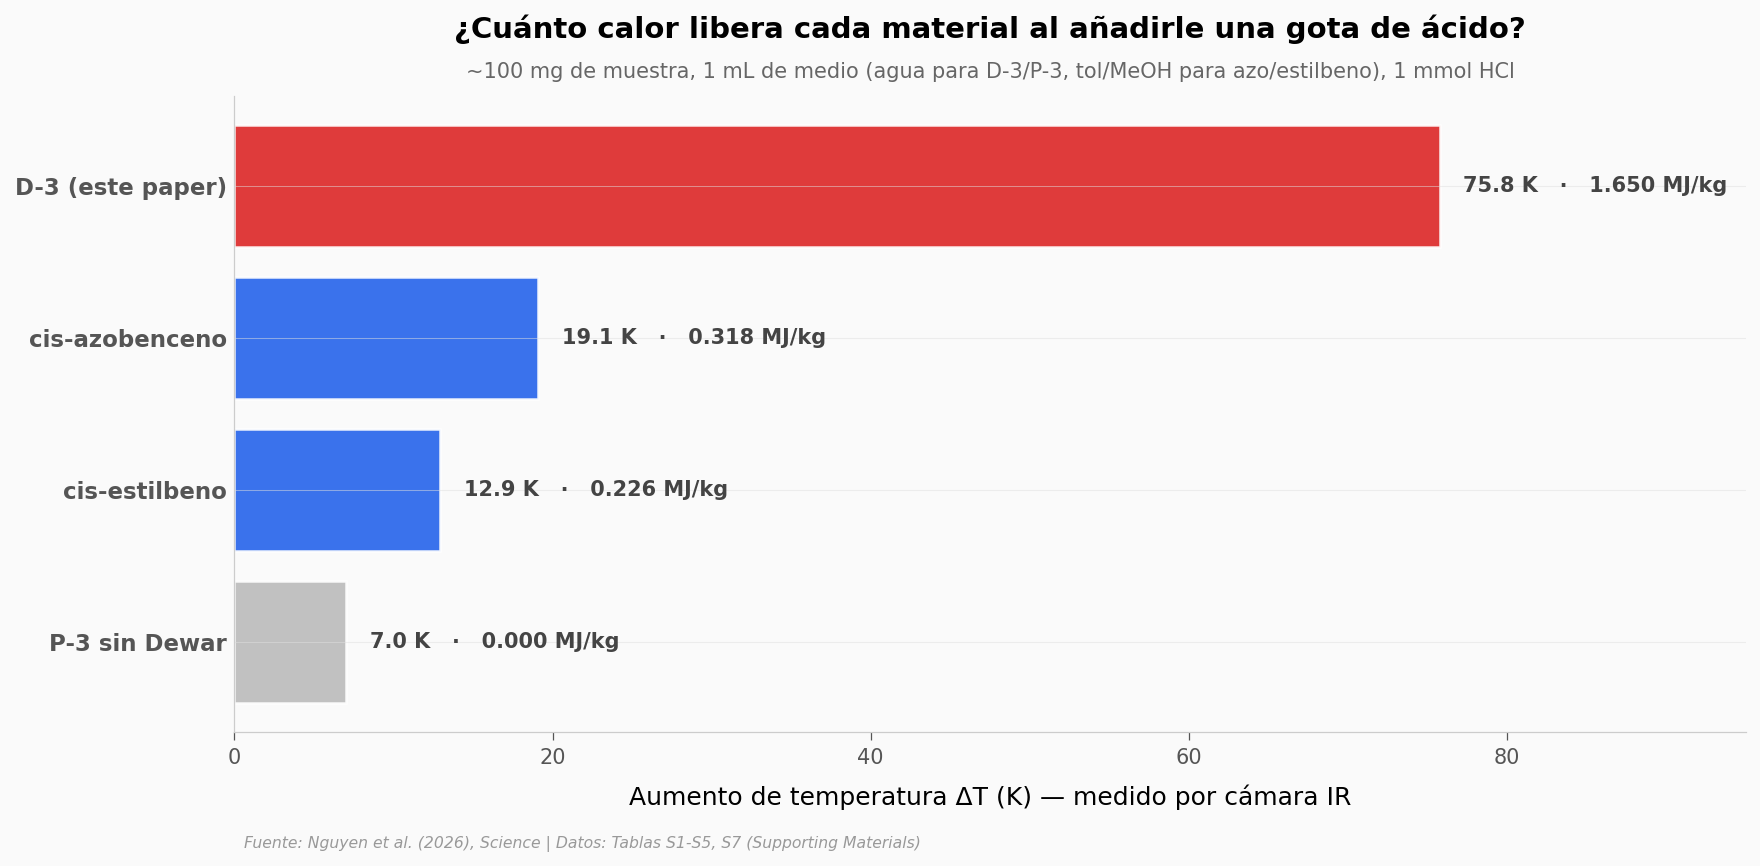

In [2]:
# Hero: comparación macroscópica del calor liberado al añadir ácido
# Filtramos los 4 experimentos comparables (~100 mg, 1 mL medio)
df_h = df_macro[df_macro['m_sample_mg'] > 100].copy()
df_h = df_h[['sample', 'delta_T_IR_K', 'delta_H_storage_MJ_kg', 'efficiency_IR_DSC']].reset_index(drop=True)

# Etiquetas legibles en español
labels_es = {
    'D-3 (MOST)':        'D-3 (este paper)',
    'P-3 (control)':     'P-3 sin Dewar',
    'cis-azobenzene':    'cis-azobenceno',
    'cis-stilbene':      'cis-estilbeno',
}
df_h['etiqueta'] = df_h['sample'].map(labels_es)
df_h['densidad_MJ_kg'] = df_h['delta_H_storage_MJ_kg']

# Ordenar de menor a mayor ΔT
df_h = df_h.sort_values('delta_T_IR_K').reset_index(drop=True)

# Asignación de colores: D-3 destaca, P-3 es el control, los otros son referencias
def color_por_muestra(s):
    if 'D-3' in s:        return COLOR_ALERTA
    if 'P-3' in s:        return COLOR_GRIS
    return COLOR_DATOS
colores = [color_por_muestra(s) for s in df_h['sample']]

fig, ax = plt.subplots(figsize=(13, 5.5))
y = np.arange(len(df_h))
bars = ax.barh(y, df_h['delta_T_IR_K'], color=colores, alpha=0.9,
               edgecolor='white', linewidth=1.2)

# Anotar cada barra: ΔT y densidad energética
for i, row in df_h.iterrows():
    delta = row['delta_T_IR_K']
    dens = row['densidad_MJ_kg']
    txt = f'{delta:.1f} K   ·   {dens:.3f} MJ/kg'
    ax.text(delta + 1.5, i, txt, va='center', fontsize=10,
            color='#444444', fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels(df_h['etiqueta'], fontsize=11, fontweight='bold')
ax.set_xlabel('Aumento de temperatura ΔT (K) — medido por cámara IR')
ax.set_xlim(0, 95)

ax.set_title('¿Cuánto calor libera cada material al añadirle una gota de ácido?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '~100 mg de muestra, 1 mL de medio (agua para D-3/P-3, tol/MeOH para azo/estilbeno), 1 mmol HCl',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/01_hero_delta_T.png', dpi=200, bbox_inches='tight')
plt.show()

**El control aísla el efecto.** P-3 sin pasar por la forma Dewar apenas calienta 7 K — eso es lo que hace el ácido por sí solo. La diferencia hasta los 76 K de D-3 viene completa de la reversión Dewar→pirimidona, no de la reacción ácido-base. Y el azobenceno, que llevaba décadas siendo la referencia, se queda en 19 K con la misma masa y volumen.

La densidad energética almacenada en D-3 es **5,2 veces** la del cis-azobenceno: 1,65 MJ/kg vs 0,318 MJ/kg. Mismo aparato, condiciones equivalentes.

## Por qué P-3, y no P-4

P-3 fue la elegida del paper. Pero entre las 4 pirimidonas sintetizadas, **no fue la del rendimiento cuántico más alto**. Veamos el compromiso real.

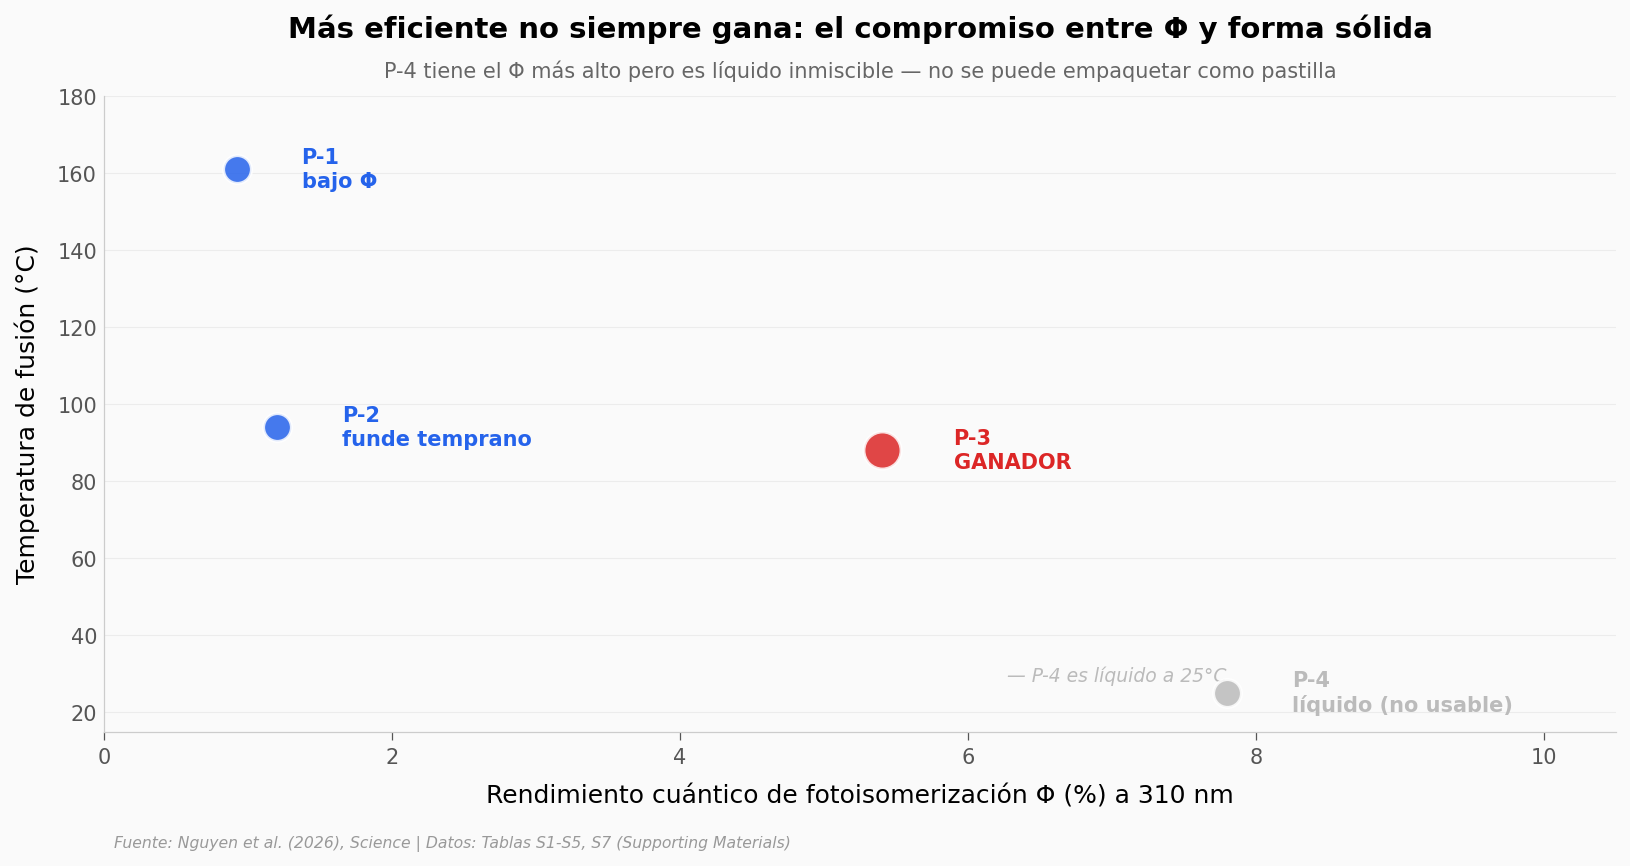

In [3]:
# Matriz Φ × punto de fusión para P-1 a P-4
df_m = df_phi.merge(df_phys, on='pyrimidone_id', how='left')

# Etiquetas y veredictos editoriales (de la tabla 'group_comparisons' del fact sheet)
veredictos = {
    'P-1': 'bajo Φ',
    'P-2': 'funde temprano',
    'P-3': 'GANADOR',
    'P-4': 'líquido (no usable)',
}
df_m['veredicto'] = df_m['pyrimidone_id'].map(veredictos)

# Para P-4 no hay Tm (es líquido a temperatura ambiente) — lo ponemos como 25°C anotado
df_m['Tm_plot'] = df_m['Tm_P_C'].fillna(25.0)

fig, ax = plt.subplots(figsize=(13, 5.5))

for i, row in df_m.iterrows():
    pid = row['pyrimidone_id']
    phi = row['quantum_yield_310nm_pct']
    tm = row['Tm_plot']
    es_ganador = (pid == 'P-3')
    es_liquido = (pid == 'P-4')
    color = COLOR_ALERTA if es_ganador else (COLOR_GRIS if es_liquido else COLOR_DATOS)
    size = 320 if es_ganador else 180
    ax.scatter(phi, tm, color=color, s=size, alpha=0.85,
               edgecolors='white', linewidths=1.5, zorder=5)
    # Etiqueta del compuesto + veredicto
    offset_x = 0.45 if not es_ganador else 0.5
    ax.text(phi + offset_x, tm,
            f'{pid}\n{row["veredicto"]}',
            fontsize=10, color=color, fontweight='bold',
            va='center', ha='left')

# Anotar la zona "líquido" para P-4
ax.axhspan(0, 30, color='#FAFAFA', alpha=0)  # placeholder
ax.text(7.8, 28, '— P-4 es líquido a 25°C', fontsize=9,
        color=COLOR_GRIS, style='italic', ha='right')

ax.set_xlabel('Rendimiento cuántico de fotoisomerización Φ (%) a 310 nm')
ax.set_ylabel('Temperatura de fusión (°C)')
ax.set_xlim(0, 10.5)
ax.set_ylim(15, 180)

ax.set_title('Más eficiente no siempre gana: el compromiso entre Φ y forma sólida',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'P-4 tiene el Φ más alto pero es líquido inmiscible — no se puede empaquetar como pastilla',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/02_phi_vs_tm.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que la teoría predijo

Antes de meterse al laboratorio, el equipo hizo cálculos de DFT (un método de química cuántica) sobre 7 variantes de pirimidona — el "padre" P-3 más 6 análogos con sustituyentes en distintas posiciones. Esos cálculos predicen tanto la densidad energética como la longitud de onda a la que cada molécula absorbe luz.

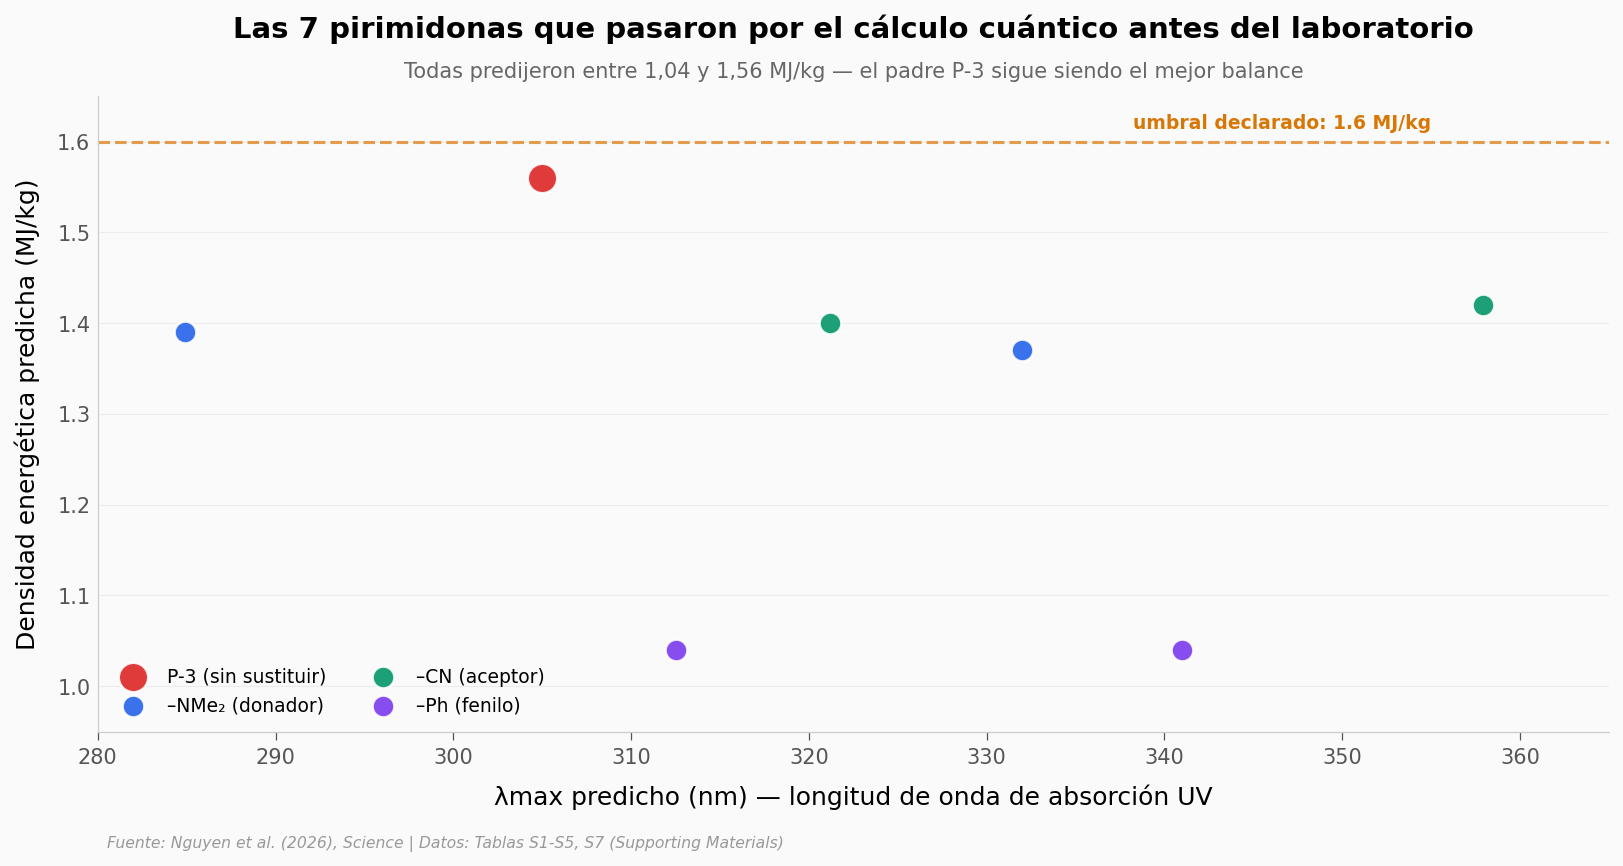

In [4]:
# DFT: densidad energética vs longitud de onda predicha
df_d = df_dft.copy()

# Categorizar el sustituyente para coloreo
def cat_sustituyente(s):
    if 'parent' in s:    return 'P-3 (sin sustituir)'
    if 'NMe2' in s:      return '–NMe₂ (donador)'
    if 'CN' in s:        return '–CN (aceptor)'
    if 'Ph' in s:        return '–Ph (fenilo)'
    return s
df_d['categoria'] = df_d['substituent'].map(cat_sustituyente)
df_d.loc[df_d['compound'] == 'P-3', 'categoria'] = 'P-3 (sin sustituir)'

categorias = ['P-3 (sin sustituir)', '–NMe₂ (donador)', '–CN (aceptor)', '–Ph (fenilo)']
colores_cat = {
    'P-3 (sin sustituir)':  COLOR_ALERTA,
    '–NMe₂ (donador)':       COLOR_DATOS,
    '–CN (aceptor)':         COLOR_SECUNDARIO,
    '–Ph (fenilo)':          COLOR_CONTRASTE,
}

fig, ax = plt.subplots(figsize=(13, 5.5))
for cat in categorias:
    sub = df_d[df_d['categoria'] == cat]
    if len(sub) == 0:
        continue
    es_padre = (cat == 'P-3 (sin sustituir)')
    ax.scatter(sub['lambda_max_nm'], sub['energy_density_MJ_kg'],
               color=colores_cat[cat], s=200 if es_padre else 110,
               alpha=0.9, edgecolors='white', linewidths=1.2,
               label=cat, zorder=5 if es_padre else 4)

# Línea de referencia: 1.6 MJ/kg umbral del título
ax.axhline(y=ENERGIA_OBJETIVO_MJ_KG, color=COLOR_REFERENCIA, linewidth=1.5,
           linestyle='--', alpha=0.7)
ax.text(355, ENERGIA_OBJETIVO_MJ_KG + 0.015, f'umbral declarado: {ENERGIA_OBJETIVO_MJ_KG} MJ/kg',
        fontsize=9, color=COLOR_REFERENCIA, fontweight='bold', ha='right')

ax.set_xlabel('λmax predicho (nm) — longitud de onda de absorción UV')
ax.set_ylabel('Densidad energética predicha (MJ/kg)')
ax.set_ylim(0.95, 1.65)
ax.set_xlim(280, 365)

ax.set_title('Las 7 pirimidonas que pasaron por el cálculo cuántico antes del laboratorio',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Todas predijeron entre 1,04 y 1,56 MJ/kg — el padre P-3 sigue siendo el mejor balance',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.legend(fontsize=9, loc='lower left', framealpha=0.9, ncol=2)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/03_dft_landscape.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan grande es el salto?

Pongamos en la misma escala lo que la teoría predijo, lo que medimos en el experimento, y los referentes clásicos del campo MOST.

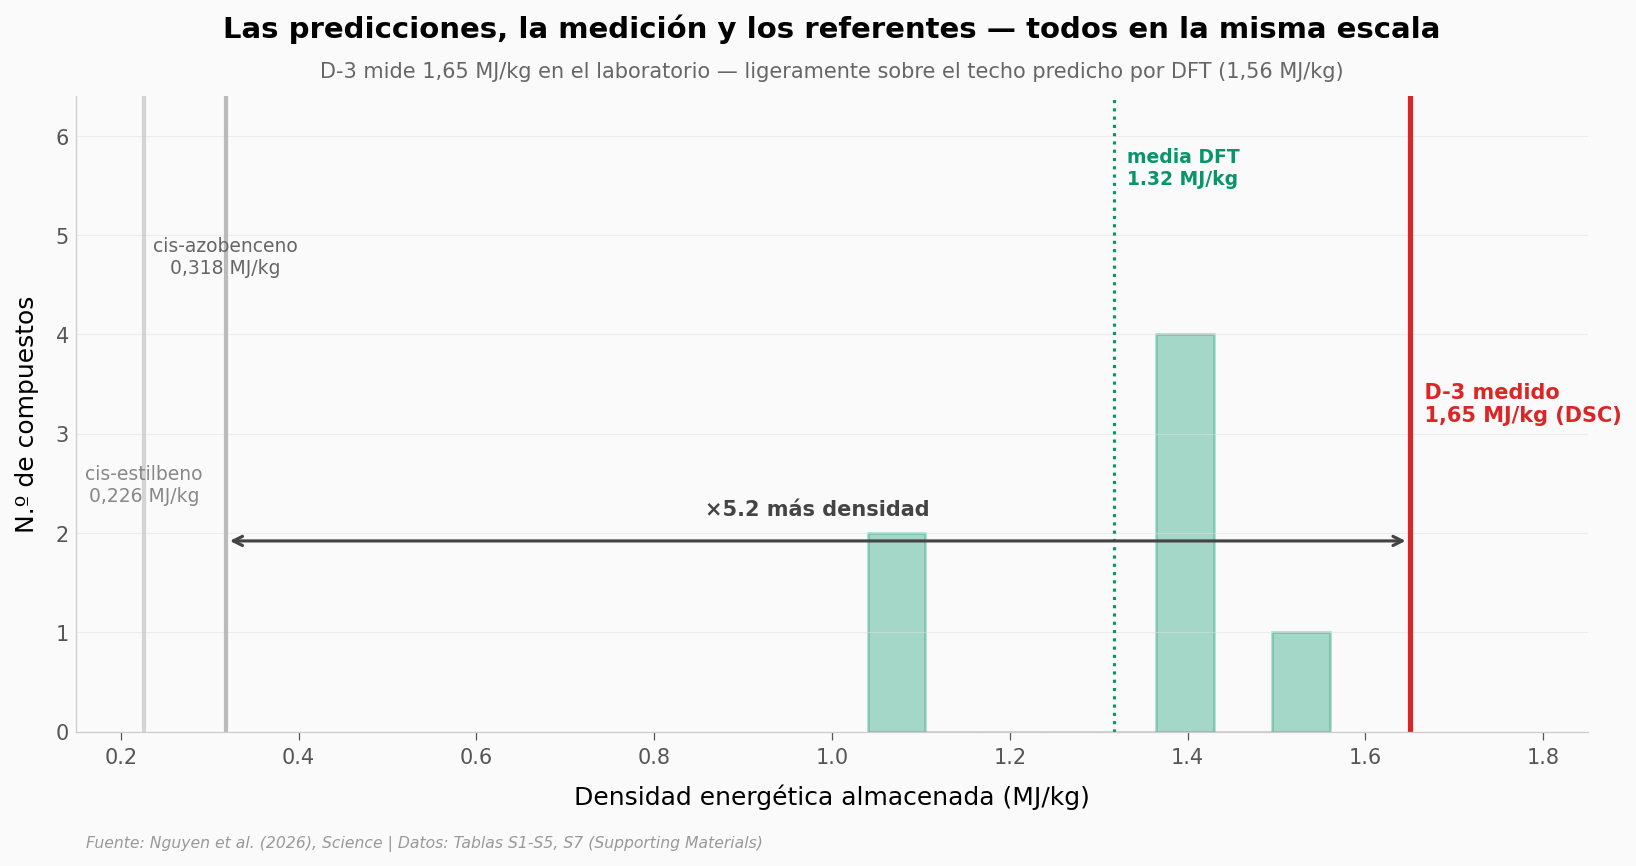

In [5]:
# Comparación: distribución DFT + medición experimental + referentes históricos
fig, ax = plt.subplots(figsize=(13, 5.5))

# Histograma de las 7 predicciones DFT
predicciones = df_dft['energy_density_MJ_kg'].values
n, bins, patches = ax.hist(predicciones, bins=8, color=COLOR_SECUNDARIO,
                            alpha=0.35, edgecolor=COLOR_SECUNDARIO,
                            linewidth=1.2, label='Predicciones DFT (n=7)')
y_max = max(n.max() * 1.6, 3.5)
ax.set_ylim(0, y_max)

# Línea: media DFT
media_dft = predicciones.mean()
ax.axvline(x=media_dft, color=COLOR_SECUNDARIO, linewidth=1.5, linestyle=':')
ax.text(media_dft, y_max * 0.92, f'  media DFT\n  {media_dft:.2f} MJ/kg',
        color=COLOR_SECUNDARIO, fontsize=9, fontweight='bold', va='top')

# Línea: D-3 medido
ax.axvline(x=1.65, color=COLOR_ALERTA, linewidth=2.5)
ax.text(1.65, y_max * 0.55, '  D-3 medido\n  1,65 MJ/kg (DSC)',
        color=COLOR_ALERTA, fontsize=10, fontweight='bold', va='top')

# Líneas: referentes históricos
ax.axvline(x=ENERGIA_AZOBENCENO_MJ_KG, color=COLOR_GRIS, linewidth=2)
ax.text(ENERGIA_AZOBENCENO_MJ_KG, y_max * 0.78, 'cis-azobenceno\n0,318 MJ/kg',
        color='#666666', fontsize=9, ha='center', va='top')
ax.axvline(x=0.226, color=COLOR_GRIS, linewidth=2, alpha=0.6)
ax.text(0.226, y_max * 0.42, 'cis-estilbeno\n0,226 MJ/kg',
        color='#888888', fontsize=9, ha='center', va='top')

# Flecha bidireccional: gap entre azobenceno y D-3
ax.annotate('', xy=(1.65, y_max * 0.30), xytext=(ENERGIA_AZOBENCENO_MJ_KG, y_max * 0.30),
            arrowprops=dict(arrowstyle='<->', color='#444444', lw=1.5))
ax.text((1.65 + ENERGIA_AZOBENCENO_MJ_KG) / 2, y_max * 0.34,
        f'×{1.65 / ENERGIA_AZOBENCENO_MJ_KG:.1f} más densidad',
        ha='center', fontsize=10, color='#444444', fontweight='bold')

ax.set_xlabel('Densidad energética almacenada (MJ/kg)')
ax.set_ylabel('N.º de compuestos')
ax.set_xlim(0.15, 1.85)

ax.set_title('Las predicciones, la medición y los referentes — todos en la misma escala',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'D-3 mide 1,65 MJ/kg en el laboratorio — ligeramente sobre el techo predicho por DFT (1,56 MJ/kg)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/04_comparacion_densidades.png', dpi=200, bbox_inches='tight')
plt.show()

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Almacena más de 1,6 MJ/kg | ✅ | Tabla S7: 1,65 MJ/kg medido por DSC en D-3 — supera el umbral del título |
| Hierve agua con catálisis ácida | ✅ | Tabla S7 exp 2: 106 mg de D-3 + 1 mmol HCl → 1 mL agua → ΔT = 75,76 K (alcanza ~100 °C desde temperatura ambiente) |
| Excita a ~300 nm | ✅ | Tabla S1: λmax de P-3 = 307 nm (el abstract redondea a 300 nm) |
| Soluble en agua | ✅ | Tabla S3: 987 ± 6 g/L para P-3 |
| Densidad 5× mayor que cis-azobenceno | ✅ | Tabla S7: 1,65 / 0,318 = 5,2× — medido en el mismo aparato |
| Vida media térmica útil a temperatura ambiente | ⚠️ | Tabla S5: ΔG‡ = 117 kJ/mol para D-3, pero la cinética se midió a 85–95 °C y se extrapoló a 25 °C. La estabilidad real a largo plazo no está medida directamente |

> **Limitaciones honestas:**
> - El embargo del dataset oficial en Dryad sigue activo al momento de este notebook — los datos vienen de las tablas agregadas del Supporting Materials (mismos experimentos, formato resumido).
> - El paper cierra diciendo que estos avances *"apuntan el camino"* (en inglés: *help point the way*) hacia almacenamiento solar descentralizado. Es un hedge intencional: lo que está demostrado es la química y la termodinámica, no el dispositivo comercial. Hervir 1 mL de agua con 100 mg de polvo no es lo mismo que calentar una casa.
> - La eficiencia de transferencia ΔH_IR/ΔH_DSC en D-3 es 87% — alta, pero las pérdidas existen. En cis-estilbeno baja a 48%.

## Ahora tú

Tres preguntas que los datos pueden responder. Cambia el código de la celda siguiente para explorar:

1. **¿Cómo cambia la capacidad calorífica con la temperatura para cada pirimidona?** Hint: agrupa `df_cp` por `pyrimidone_id` y graficar `temperature_C` vs `Cp_J_g-1_K-1`.
2. **¿Hay correlación entre el ΔS de activación y la energía de activación entre los Dewars?** Hint: `df_kin` tiene 3 filas — un scatter pequeño basta.
3. **¿Qué pasaría si el rendimiento cuántico de P-3 fuera el de P-4 (7,8% en lugar de 5,4%)?** ¿Cuántas veces menos tiempo de irradiación necesitarías para llenar la misma masa de Dewar? Pista: la velocidad de generación es proporcional a Φ.

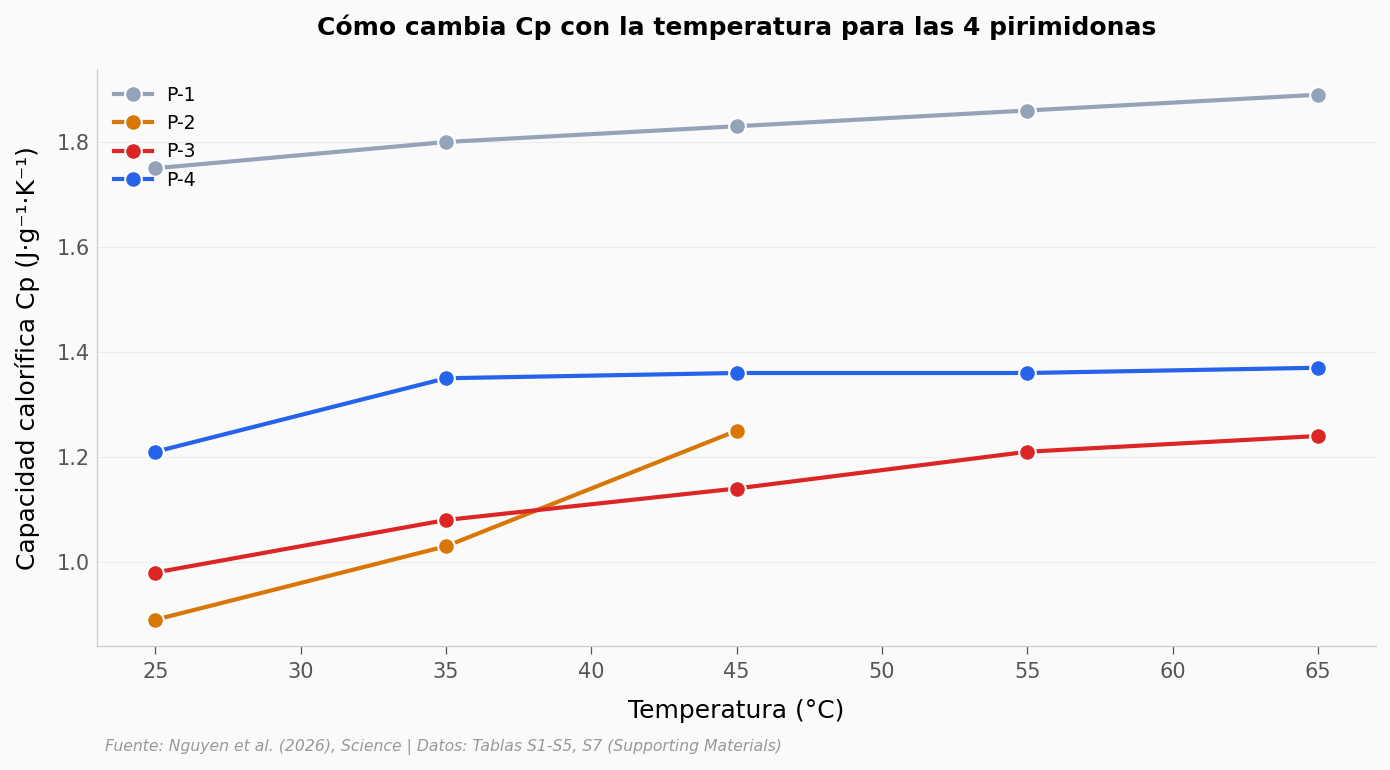


Cp a 25°C:
  P-1: 1.75 J/g/K
  P-2: 0.89 J/g/K
  P-3: 0.98 J/g/K
  P-4: 1.21 J/g/K


In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: capacidad calorífica vs temperatura para cada pirimidona
fig, ax = plt.subplots(figsize=(11, 5))
colores_p = {'P-1': '#94A3B8', 'P-2': COLOR_REFERENCIA, 'P-3': COLOR_ALERTA, 'P-4': COLOR_DATOS}
for pid, sub in df_cp.groupby('pyrimidone_id'):
    sub = sub.sort_values('temperature_C')
    ax.plot(sub['temperature_C'], sub['Cp_J_g-1_K-1'],
            marker='o', linewidth=2, markersize=8,
            color=colores_p[pid], label=pid,
            markeredgecolor='white', markeredgewidth=1)

ax.set_xlabel('Temperatura (°C)')
ax.set_ylabel('Capacidad calorífica Cp (J·g⁻¹·K⁻¹)')
ax.set_title('Cómo cambia Cp con la temperatura para las 4 pirimidonas',
             fontsize=12, fontweight='bold', pad=16)
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.show()

# Imprime un resumen para que veas los números
print('\nCp a 25°C:')
for pid in ['P-1', 'P-2', 'P-3', 'P-4']:
    cp25 = df_cp[(df_cp['pyrimidone_id'] == pid) & (df_cp['temperature_C'] == 25)]
    if not cp25.empty:
        print(f'  {pid}: {cp25.iloc[0]["Cp_J_g-1_K-1"]:.2f} J/g/K')

---

## Fuentes

**Paper**: [Molecular solar thermal energy storage in Dewar pyrimidone beyond 1.6 megajoules per kilogram](https://doi.org/10.1126/science.aec6413)  
*Science, 2026-04-23*

**Supporting Materials**: [Tablas S1-S7 + figuras S1-S56](https://www.science.org/doi/suppl/10.1126/science.aec6413/suppl_file/science.aec6413_sm.pdf)

**Datos**: [Data for: Molecular solar thermal energy storage in Dewar Pyrimidone beyond 1.6 MJ/kg](https://datadryad.org/dataset/doi:10.5061/dryad.rxwdbrvqg)  
*Dryad — estado* submitted *al momento de la consulta (embargo de curación)*

*21 afirmaciones verificadas contra estas fuentes*

---

**Reproducibilidad:** este notebook usa solamente Python estándar (pandas, numpy, matplotlib) y los CSVs incluidos en `datos/`. Cualquier persona puede correrlo en su máquina o en Google Colab.

**Licencia:** [MIT](https://github.com/Ciencia-a-Mordiscos/lab/blob/main/LICENSE) · **Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)